In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.TimeSeriesAnalysis import select_random_json, create_folder, read_experiment_json, compute_means_for_folder_tests
from src.analysis_L_min_functions import detect_equilibrium_start_with_errors, idx_from_t0, weighted_mean_and_sem, read_mean_json, calculate_means_L, generate_pc_estimate
plt.style.use('properties.mplstyle')
import os

In [3]:
results_folder = "../tests_L_min/3D/"
create_folder(results_folder)

## COMPUTE MEANS FOR FOLDERS

In [ ]:
DIM = 3
N_COLORS = 2
NT = 3000
K = 1.0e-6
RHO = 1/N_COLORS
p0 = [1.0]

L_lst = calculate_means_L(N_COLORS, DIM, NT, K, RHO, p0)
df = generate_pc_estimate(L_lst, N_COLORS,DIM, NT, K, RHO)

[ok] p0=1.00: 50 arquivos | seeds=50 | pc_SOP=0.297648±0.000108
[salvo] ../Data_tests/bond_percolation/num_colors_2/dim_3/L_220/NT_constant/NT_3000/k_1.0e-06/rho_5.0000e-01/properties_mean_bundle.json
[ok] p0=1.00: 10 arquivos | seeds=10 | pc_SOP=0.301986±0.000260
[salvo] ../Data_tests/bond_percolation/num_colors_2/dim_3/L_215/NT_constant/NT_3000/k_1.0e-06/rho_5.0000e-01/properties_mean_bundle.json
[ok] p0=1.00: 50 arquivos | seeds=50 | pc_SOP=0.285441±0.000086
[salvo] ../Data_tests/bond_percolation/num_colors_2/dim_3/L_240/NT_constant/NT_3000/k_1.0e-06/rho_5.0000e-01/properties_mean_bundle.json
[ok] p0=1.00: 60 arquivos | seeds=60 | pc_SOP=0.283083±0.000063
[salvo] ../Data_tests/bond_percolation/num_colors_2/dim_3/L_245/NT_constant/NT_3000/k_1.0e-06/rho_5.0000e-01/properties_mean_bundle.json
[ok] p0=1.00: 50 arquivos | seeds=50 | pc_SOP=0.294113±0.000090
[salvo] ../Data_tests/bond_percolation/num_colors_2/dim_3/L_225/NT_constant/NT_3000/k_1.0e-06/rho_5.0000e-01/properties_mean_bundle.

In [3]:
df = pd.DataFrame(data=all_data).sort_values(by=['L'])
df

,L,nc,dim,t0,pc,pc_err,err_rel,order
13,200,2,3,186.0,0.265393,0.000042,6.664284,2
12,200,2,3,186.0,0.264680,0.000040,6.377484,1
19,205,2,3,143.0,0.263992,0.000033,6.101224,2
18,205,2,3,143.0,0.264400,0.000037,6.264930,1
15,210,2,3,126.0,0.263001,0.000033,5.702886,2
14,210,2,3,126.0,0.263285,0.000037,5.816978,1
2,215,2,3,190.0,0.262308,0.000035,5.424164,1
3,215,2,3,190.0,0.261593,0.000041,5.136800,2
0,220,2,3,262.0,0.261086,0.000019,4.932938,1
1,220,2,3,262.0,0.260971,0.000019,4.886856,2


## MULTI SAMPLE

t0 individual: 251.00, 220.00
t0 GLOBAL (usado para ambas): 251.00
[serie 0] mean_eq=0.25638688 ± 0.00002855
3.044492757601805
[serie 1] mean_eq=0.25619726 ± 0.00002927
2.9682838476593596


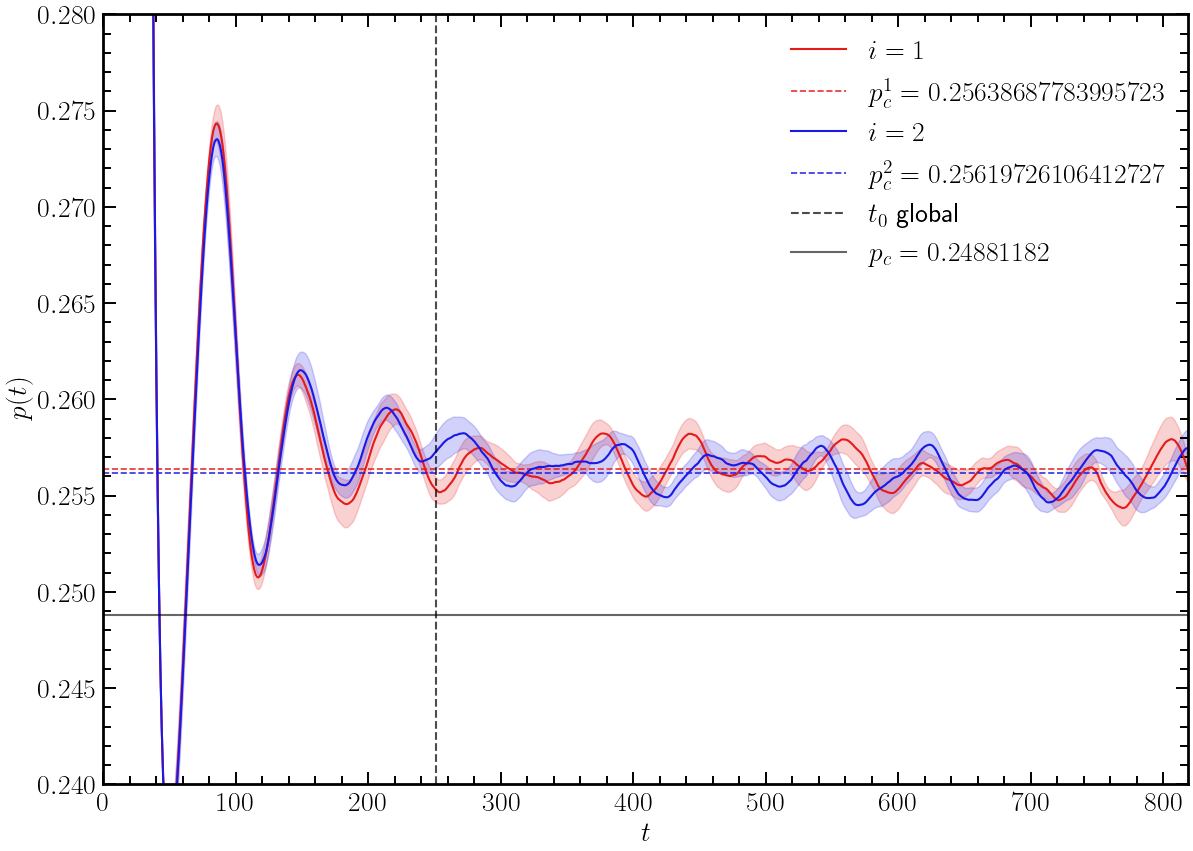

In [27]:
import json
import numpy as np
import matplotlib.pyplot as plt
# ------------------ USO ------------------

DIM = 3
N_COLORS = 2
L = 265
NT = 3000
K = 1.0e-6
RHO = 1/N_COLORS

data = read_mean_json(N_COLORS, DIM, L, NT, K, RHO)

colors_used = [
    (0.9, 0.1, 0.1),  # 2 - red
    (0.1, 0.1, 0.9),  # 5 - blue
    (0.1, 0.9, 0.1),  # 4 - green
    (1.0, 0.5, 0.0),  # 3 - orange
    (0.8, 0.2, 0.8),  # 6 - purple
    (0.2, 0.8, 0.8),  # 7 - teal
    (1.0, 1.0, 0.0),  # 8 - yellow
    (0.6, 0.4, 0.2),  # 9 - brown
]

ls = ['solid', 'dotted', 'dashed', 'dashdot', (0, (3, 5, 1, 5)),
      (0, (3, 10, 1, 10)), (5, (10, 3)), (0, (3, 1, 1, 1, 1, 1)),
      (0, (3, 10, 1, 10, 1, 10))]

pc = 0.24881182

# lê as 2 séries
series = []
for i in range(2):
    d = data[i]["data"]
    t = np.array(d["time"], dtype=float)
    pt = np.array(d["pt_mean"], dtype=float)
    pt_sem = np.array(d["pt_sem"], dtype=float)
    series.append((t, pt, pt_sem))

# estima t0 individual e pega t0 global (mais tardio)
t0_ind = []
for (t, pt, pt_sem) in series:
    idx0_i = detect_equilibrium_start_with_errors(t, pt, pt_sem, w=40, consec=6, z=2.0, chi2r_max=2.0)
    t0_ind.append(t[idx0_i])

t0_global = float(max(t0_ind))

print(f"t0 individual: {t0_ind[0]:.2f}, {t0_ind[1]:.2f}")
print(f"t0 GLOBAL (usado para ambas): {t0_global:.2f}")

# plot e linhas no mean_eq
for i, (t, pt, pt_sem) in enumerate(series):
    idx0_g = idx_from_t0(t, t0_global)

    mean_eq, sem_eq = weighted_mean_and_sem(pt[idx0_g:], pt_sem[idx0_g:])
    print(f"[serie {i}] mean_eq={mean_eq:.8f} ± {sem_eq:.8f}")

    # curva + faixa sombreada
    plt.plot(t, pt, label=f"$i = {i+1}$", ls='-', color=colors_used[i])
    plt.fill_between(t, pt - pt_sem, pt + pt_sem, alpha=0.20, color=colors_used[i])

    # linha tracejada no mean_eq dessa série (mesma cor da curva)
    #color = plt.gca().lines[-1].get_color()
    plt.axhline(mean_eq, linestyle="--", linewidth=1.2, label = f'$p_c^{i+1} = {mean_eq}$', alpha=0.9, color=colors_used[i])
    err = (abs(mean_eq - pc)/pc)*100
    print(err)
# marca t0 global
plt.axvline(t0_global, linestyle="--", linewidth=1.5, color="k", alpha=0.7, label="$t_0$ global")

# referência pc
plt.axhline(y=pc, linestyle="-", color="k",label=f'$p_c = {pc}$' ,alpha=0.6)
plt.xlabel(r'$t$')
plt.ylabel(r'$p(t)$')
plt.xlim(0, max(series[0][0]))
plt.ylim(0.24, 0.28)
plt.legend()
plt.show()
